# Handling missing values
- Handling missing values is an essential part of data cleaning and preparation process because almost all data in real life comes with some missing values.
- In Pandas missing data is represented by two value:
    - None: None is a Python singleton object that is often used for missing data in Python code.
    - NaN : NaN (an acronym for Not a Number), is a special floating-point value recognized by all systems that use the standard IEEE floating-point representation
- Pandas treat **None and NaN** as essentially interchangeable for indicating missing or null values.
- here are several useful functions for detecting, removing, and replacing null values in Pandas DataFrame :
    - isnull()/isna()
    - notnull()
    - dropna()
    - fillna()
    - replace()
    - interpolate()

In [ ]:
import pandas as pd
import numpy as  np
from sklearn.impute import SimpleImputer

### Using the "axis" parameter in pandas
- Series object has only “axis 0” because it has only one dimension.
- A DataFrame object has two axes: “axis 0” and “axis 1”. “axis 0” represents rows and “axis 1” represents columns. Now it’s clear that Series and DataFrame share the same direction for “axis 0” – it goes along rows direction.
- DataFrame has two axes, and “axis” parameter determines along which axis an operation should be performed. For example, .sum can be applied along “axis 0”. That means, .sum operation calculates a sum for each column:

In [ ]:
a= pd.Series([10,30,60,80,90])
b=pd.Series([22, 44, 55, 77, 101])
df=pd.DataFrame({'x':a,'y':b})
print(df)

    x    y
0  10   22
1  30   44
2  60   55
3  80   77
4  90  101


In [ ]:
df.sum(axis=0) # or df.sum(axis='rows')

x    270
y    299
dtype: int64

In [ ]:
df.sum()

x    270
y    299
dtype: int64

In [ ]:
df.sum(axis=1) #With axis=1 it produces a sum for each row: # or df.sum(axis='columns')

0     32
1     74
2    115
3    157
4    191
dtype: int64

In [ ]:
df=pd.read_csv('employees.csv')

In [ ]:
df.shape

(980, 8)

In [ ]:
df.head(10)

,First Name,Gender,Start Date,Last Login Time,Salary,Bonus %,Senior Management,Team
0,Douglas,Male,08-06-1993,12:42 PM,97308,6.945,True,Marketing
1,Douglas,Male,08-06-1993,12:42 PM,97308,6.945,True,Marketing
2,Thomas,Male,3/31/1996,6:53 AM,61933,4.170,True,NaN
3,Maria,Female,4/23/1993,11:17 AM,130590,11.858,False,Finance
4,Jerry,Male,03-04-2005,1:00 PM,138705,9.340,True,Finance
5,Jerry,Male,03-04-2005,1:00 PM,138705,9.340,True,Finance
6,Larry,Male,1/24/1998,4:47 PM,101004,1.389,True,Client Services
7,Dennis,Male,4/18/1987,1:35 AM,115163,10.125,False,Legal
8,Ruby,Female,8/17/1987,4:20 PM,65476,10.012,True,Product
9,NaN,Female,7/20/2015,10:43 AM,45906,11.598,NaN,Finance


### Checking for missing values using isnull() and notnull()
- In order to check null values in Pandas DataFrame, we use isnull() function this function return dataframe of Boolean values which are True for NaN values.
- notnull() is opposite to isnull()

In [ ]:
df.isna()

,First Name,Gender,Start Date,Last Login Time,Salary,Bonus %,Senior Management,Team
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,True
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
975,False,False,False,False,False,False,False,False
976,False,False,False,False,False,False,False,False
977,False,False,False,False,False,False,False,False
978,False,False,False,False,False,False,False,False


In [ ]:
df = pd.DataFrame([[1,      np.nan, 2],
                   [2,      3,      5],
                   [np.nan, 4,      6],
                  [None,np.nan, 2]])
print(df)

     0    1  2
0  1.0  NaN  2
1  2.0  3.0  5
2  NaN  4.0  6
3  NaN  NaN  2


In [ ]:
df.isnull()

,0,1,2
0,False,True,False
1,False,False,False
2,True,False,False
3,True,True,False


In [ ]:
df.isna().any()

0     True
1     True
2    False
dtype: bool

In [ ]:
df.isna().sum()

0    2
1    2
2    0
dtype: int64

### When Missing values are in data
- When summing data, NA (missing) values will be treated as zero.
- If the data are all NA, the result will be 0.

### handling missing values using dropna(),fillna(), replace() and interpolate()

### Dropping null values

In [ ]:
df.dropna()

,0,1,2
1,2.0,3.0,5


In [ ]:
df.dropna(axis=1)

,2
0,2
1,5
2,6
3,2


In [ ]:
df.dropna(axis=0)  # Rows with at least one missing value have been dropped.

,0,1,2
1,2.0,3.0,5


In [ ]:
df.dropna(axis='rows', thresh=2)

,0,1,2
0,1.0,NaN,2
1,2.0,3.0,5
2,NaN,4.0,6


In [ ]:
#  the thresh parameter lets you specify a minimum number of non-null values for the row/column to be kept:
df.dropna(axis='columns', thresh=2)

,0,1,2
0,1.0,NaN,2
1,2.0,3.0,5
2,NaN,4.0,6
3,NaN,NaN,2


### Filling missing values using fill() and replace()
these are the available filling methods:

- Method fill()
    - pad / ffill--Fill values forward
    - bfill / backfill--Fill values backward

In [ ]:
df.fillna(method='pad')

,0,1,2
0,1.0,NaN,2
1,2.0,3.0,5
2,2.0,4.0,6
3,2.0,4.0,2


In [ ]:
df.fillna(method='bfill')

,0,1,2
0,1.0,3.0,2
1,2.0,3.0,5
2,NaN,4.0,6
3,NaN,NaN,2


In [ ]:
df.replace(to_replace=np.nan,value=-99)

,0,1,2
0,1.0,-99.0,2
1,2.0,3.0,5
2,-99.0,4.0,6
3,-99.0,-99.0,2


In [ ]:
m=df.mean()
print(m)

0    1.50
1    3.50
2    3.75
dtype: float64


In [ ]:
df.fillna(m)

,0,1,2
0,1.0,3.5,2
1,2.0,3.0,5
2,1.5,4.0,6
3,1.5,3.5,2


### Interpolation to fill missing values
- Both Series and DataFrame objects have interpolate() that, by default, performs linear interpolation at missing data points.
- The method argument gives access to fancier interpolation methods.
- The appropriate interpolation method will depend on the type of data you are working with.
    - If you are dealing with a time series that is growing at an increasing rate, method='quadratic' may be appropriate.
    - If you have values approximating a cumulative distribution function, then method='pchip' should work well.
    - To fill missing values with goal of smooth plotting, consider method='akima'.

In [ ]:
df.interpolate()

,0,1,2
0,1.0,NaN,2
1,2.0,3.0,5
2,2.0,4.0,6
3,2.0,4.0,2


In [ ]:
df.interpolate(method='akima')

,0,1,2
0,1.0,NaN,2
1,2.0,3.0,5
2,NaN,4.0,6
3,NaN,NaN,2


In [ ]:
df.interpolate(limit=1)

,0,1,2
0,1.0,NaN,2
1,2.0,3.0,5
2,2.0,4.0,6
3,NaN,4.0,2


In [ ]:
df.fillna(m,inplace=True)
print(df)

     0    1  2
0  1.0  3.5  2
1  2.0  3.0  5
2  1.5  4.0  6
3  1.5  3.5  2


In [ ]:
df = pd.DataFrame([[1,      np.nan, 2],
                   [2,      3,      5],
                   [np.nan, 4,      6],
                  [None,np.nan, 2]])
# Imputer object using the mean strategy
imputer = SimpleImputer(missing_values = np.nan,
                        strategy ='mean')
# Fitting the data to the imputer object
imputer = imputer.fit(df)

# Imputing the data
data = imputer.transform(df)
print(data)

[[1.  3.5 2. ]
 [2.  3.  5. ]
 [1.5 4.  6. ]
 [1.5 3.5 2. ]]


In [ ]:
from numpy import nan
from pandas import read_csv
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
# load the dataset
dataset = read_csv('diabetes.csv', header=None)
# replace '0' values with 'nan'
dataset[[1,2,3,4,5]] = dataset[[1,2,3,4,5]].replace(0, nan)
# split dataset into inputs and outputs
values = dataset.values
X = values[:,0:8]
y = values[:,8]
# define the model
model = LinearDiscriminantAnalysis()
# define the model evaluation procedure
cv = KFold(n_splits=3, shuffle=True, random_state=1)
# evaluate the model
result = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
# report the mean performance
print('Accuracy: %.3f' % result.mean())

Accuracy: nan


C:\Users\student\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:536: FitFailedWarning: Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
ValueError: Input contains NaN, infinity or a value too large for dtype('float64').

  FitFailedWarning)
C:\Users\student\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:536: FitFailedWarning: Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
ValueError: Input contains NaN, infinity or a value too large for dtype('float64').

  FitFailedWarning)
C:\Users\student\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:536: FitFailedWarning: Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
ValueError: Input contains NaN, infinity or a value too large for dtype('float64').

  FitFailedWarning)


In [ ]:
from numpy import nan
from pandas import read_csv
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
# load the dataset
dataset = read_csv('diabetes.csv', header=None)
# replace '0' values with 'nan'
dataset[[1,2,3,4,5]] = dataset[[1,2,3,4,5]].replace(0, nan)
# drop rows with missing values
dataset.dropna(inplace=True)
# split dataset into inputs and outputs
values = dataset.values
X = values[:,0:8]
y = values[:,8]
# define the model
model = LinearDiscriminantAnalysis()
# define the model evaluation procedure
cv = KFold(n_splits=3, shuffle=True, random_state=1)
# evaluate the model
result = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
# report the mean performance
print('Accuracy: %.3f' % result.mean())

Accuracy: 0.781


## Removing duplicates from data using pandas
- Pandas drop_duplicates() function removes duplicate rows from the DataFrame. Its syntax is:
    - drop_duplicates(self, subset=None, keep="first", inplace=False)
- subset: column label or sequence of labels to consider for identifying duplicate rows. By default, all the columns are used to find the duplicate rows.
- keep: allowed values are {‘first’, ‘last’, False}, default ‘first’. If ‘first’, duplicate rows except the first one is deleted. If ‘last’, duplicate rows except the last one is deleted. If False, all the duplicate rows are deleted.
- inplace: if True, the source DataFrame is changed and None is returned. By default, source DataFrame remains unchanged and a new DataFrame instance is returned.

In [ ]:
data = {"Name": ["James", "Alice", "Phil", "James"],"Age": [24, 28, 40, 25],"Sex": ["Male", "Female", "Male", "Male"]}
df = pd.DataFrame(data)
print(df)


    Name  Age     Sex
0  James   24    Male
1  Alice   28  Female
2   Phil   40    Male
3  James   25    Male


### How to Find if one or More Columns Duplicated in Pandas

In [ ]:
df['Name'].duplicated()

0    False
1    False
2    False
3     True
Name: Name, dtype: bool

### Drop Duplicate Rows

In [ ]:
df.drop_duplicates()

,Name,Age,Sex
0,James,24,Male
1,Alice,28,Female
2,Phil,40,Male
3,James,25,Male


### To remove duplicates of only one or a subset of columns
- In our example data, this could be useful if we had two entries for Name = James, one with Age = 24 and one with Age = 25. If we know we only want the oldest example for each person, we can sort by Age and drop duplicates of the name column, keeping only the observation with the highest age.

In [ ]:
df = df.sort_values('Age', ascending=False)
df.drop_duplicates(subset='Name', keep='first',inplace=False)


,Name,Age,Sex
2,Phil,40,Male
1,Alice,28,Female
3,James,25,Male


In [ ]:
df.drop_duplicates(subset='Name', keep='last',inplace=False)

,Name,Age,Sex
2,Phil,40,Male
1,Alice,28,Female
0,James,24,Male


In [ ]:
df

,Name,Age,Sex
2,Phil,40,Male
1,Alice,28,Female
3,James,25,Male
0,James,24,Male


## Handling Outliers

In [1]:
import numpy as np
from scipy import stats

# Sample data
data = np.array([10, 12, 12, 13, 12, 11, 14, 13, 15, 10, 102, 12, 14, 17, 10, 13, 12, 11, 14, 12, 10])

# Calculate absolute Z-scores
z_scores = np.abs(stats.zscore(data))

# Define threshold
threshold = 3

# Identify outliers and non-outliers
outliers = data[z_scores > threshold]
non_outliers = data[z_scores <= threshold]

print("Original Data:", data)
print("Z-scores:", z_scores)
print("Outliers (Z-score > {}):".format(threshold), outliers)
print("Data without Outliers:", non_outliers)

Original Data: [ 10  12  12  13  12  11  14  13  15  10 102  12  14  17  10  13  12  11
  14  12  10]
Z-scores: [0.34524387 0.24092558 0.24092558 0.18876643 0.24092558 0.29308472
 0.13660729 0.18876643 0.08444814 0.34524387 4.4533975  0.24092558
 0.13660729 0.01987015 0.34524387 0.18876643 0.24092558 0.29308472
 0.13660729 0.24092558 0.34524387]
Outliers (Z-score > 3): [102]
Data without Outliers: [10 12 12 13 12 11 14 13 15 10 12 14 17 10 13 12 11 14 12 10]


In [2]:
import numpy as np

data = [1, 2, 3, 4, 100, 5, 6, 7]
Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = [x for x in data if x < lower_bound or x > upper_bound]
print(f"Outliers using IQR: {outliers}")

Outliers using IQR: [100]


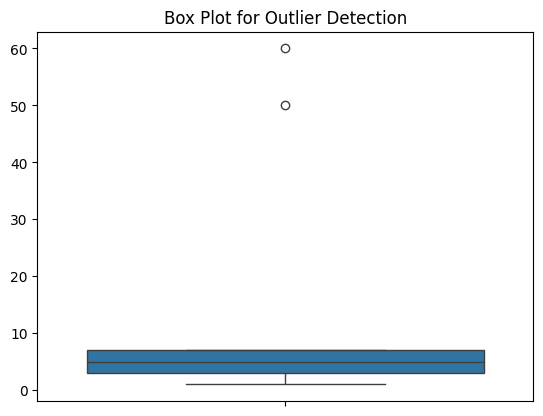

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

data = [1, 2, 3, 4, 50,60, 5, 6, 7]
sns.boxplot(data)
plt.title("Box Plot for Outlier Detection")
plt.show()

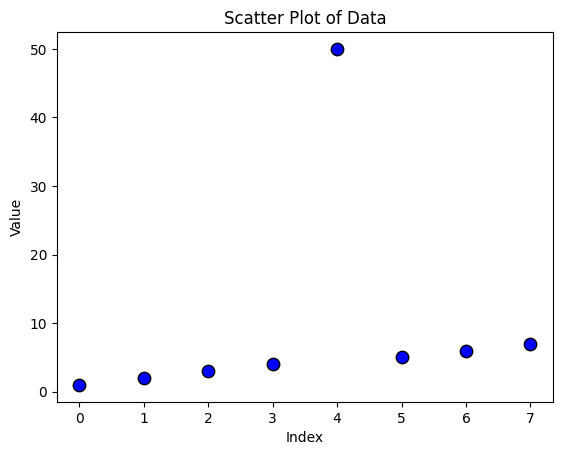

In [5]:
import matplotlib.pyplot as plt

data = [1, 2, 3, 4, 50, 5, 6, 7]

# X-axis as index positions
x = range(len(data))

# Scatter plot
plt.scatter(x, data, color="blue", s=80, edgecolor="black")
plt.title("Scatter Plot of Data")
plt.xlabel("Index")
plt.ylabel("Value")
plt.show()
